# Exercises

Import necessary libraries:

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (15,3)

## Exercise 1: What view of probability is more appropriate?

Decide whether you would rather use a **frequentist** or a **Bayesian** understanding of probability
to answer the following problems:

### a)

**A medical researcher wants to determine the exact rate of prostate cancer for males between 50 and 60 in Switzerland**

Frequentist approach could be used here, divide the number of cancer cases by the male Swiss population between 50 and 60, seeing cancer as a Bernoulli experiment and treating all individuals equally. We will see next week that this can also be formulated as a continuous problem from a Bayesian viewpoint.

###  b)

**A gambler goes into a casino and looks for the game with the highest probability of winning money**

There is not much subjectivity in games and games are highly repeatable experiments, so a Frequentist view can be preferred. This would of course be different if the rules of the games were not known beforehand.

### c)

**A poker player wants to create a mathematical model that predicts the moves of his opponents. He knows the strategies
   of most of his opponents quite well**

Frequentist statistics cannot incorporate prior information, so a Bayesian view is preferred here.

### d)

**A particle physicist has run an interesting experiment. Now she wants to assess whether the collected data puts the
   standard model of particle physics into question. From her education she knows that a long series of experiments have
   confirmed the standard model**

Frequentist models can only be used to assess the probability of data under a hypothesis. In principle, the physicist could check how probable her data are under the assumption of the standard model and reject this null hypothesis when a sufficiently small p-value is reached. This can be dangerously misleading, as unlikely data could also have been produced by a faulty experiment. It's better to choose a Bayesian viewpoint and to assess the probability (plausibility, degree of belief in) of the standard model or an alternative hypothesis and take into account the prior belief that her small experiment might not be enough to challenge an established and well-tested theory.

### e)

**An insurance company wants to estimate the number of car accidents per year in their portfolio to guess what reserves
   they have to put aside**

Car accidents can be seen as a repeatable random experiment and a Frequentist view can be assumed. However a Frequentist approach can only take into account historical data (e.g. observing and modelling a trend in car accidents) and not other expert-level data, such as the introduction of new laws (e.g. stronger tests of older people).

### f)

**An economist predicts inflation rates in different countries for the next year**

While historical data might be of some use in the prediction of inflation rates, they are probably mostly driven by expert knowledge about markets, conflicts, etc, so a Bayesian approach might be preferred.

### g)

**A doctor is asking himself whether you could have scabies**

The doctor has assessed your symptoms (data) and can ask himself two different questions: What is the probability P(symptoms|scabies) that wou would have these symptoms given you have scabies? Are there infections or diseases with a higher probability for this symptoms? (Frequentist view) Under a Bayesian view, he could directly evaluate P(scabies|symptoms), a degree of belief in that you have scabies. The latter is much more straightforward.

### h)

**An engineer is in charge of a production process producing thousands of special screws throughout a day. Her boss asks
   her to give an estimate of the rate of defective screws**

Producing a large amount of screws is a highly repeatable experiment, so a Frequentist view (uncertainty is in the object) could be preferred. However, if only an extremely small number of screws is actually defective (say one in a million), then the Bayesian viewpoint might perform better because its abilities to deal better with few-sample situations.

## Exercise 2: The law of large numbers

The **law of large numbers** states that a relative frequency will stabilize in the limit of large numbers
(respectively, as $N \to \infty$).

Write a short NumPy code that

- simulates $N$ coin tosses,
- computes the *cumulative relative frequency* of heads after each toss,
- and visualizes this cumulative relative frequency (e.g. with a line plot).

Answer the following questions:

1. Does your simulation stably reach $0.5$ in the limit of large $N$?
2. How large does $N$ approximately need to be to reach at least three zeros behind the $0.5$ (i.e. about $0.500$)?
   Alternatively: three nines behind $0.4$ (i.e. about $0.499$).


Simulate coin tosses:

In [35]:
N_tosses = 1000
tosses = np.random.randint(2, size=N_tosses)
tosses[:20]

array([1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0])

Compute cumulative relative frequencies (aka frequentist probabilities):

In [36]:
cum_tosses = np.arange( 1, N_tosses+1, 1)
probs = np.cumsum( tosses ) / cum_tosses
probs[:20]

array([1.        , 1.        , 0.66666667, 0.5       , 0.4       ,
       0.33333333, 0.28571429, 0.375     , 0.33333333, 0.3       ,
       0.36363636, 0.33333333, 0.30769231, 0.35714286, 0.4       ,
       0.375     , 0.41176471, 0.38888889, 0.42105263, 0.4       ])

Final probability:

In [37]:
probs[-1]

0.482

Visualize:

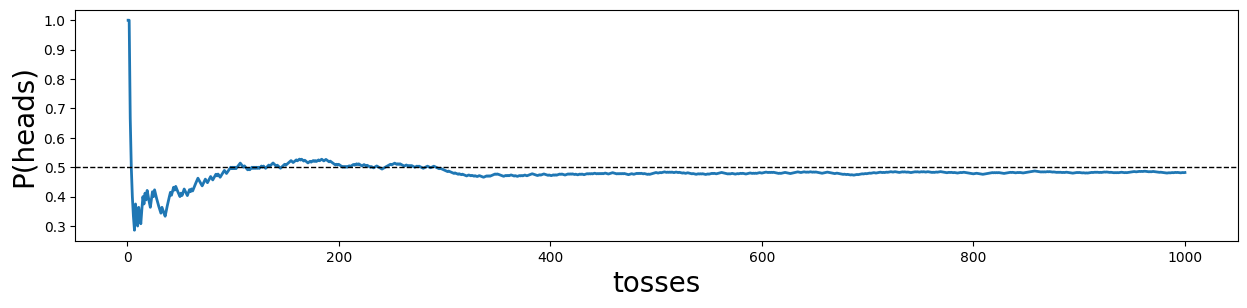

In [38]:
plt.figure( figsize=(15,3) )
plt.plot( cum_tosses, probs, lw=2 )
plt.xlabel("tosses", fontsize=20)
plt.ylabel("P(heads)", fontsize=20)
plt.axhline(0.5, c="black", lw=1, ls="--")

In [39]:
probs[-1]

0.482

As you can find out with trial and error, to reach more or less stably a 0.5000 or 0.4999, around $N=100$ Million coin tosses are needed! This can also be justified approximately by looking at the formula for the variance around $\hat{\pi} = 0.5$:

$$
\text{Var}[\hat{\pi}] = \text{Var}\left[\frac{k}{n}\right] = \frac{1}{n^2} \text{Var}[k] = \frac{1}{n^2} n \; \hat{\pi} \; (1-\hat{\pi}) = \frac{\hat{\pi} \; (1-\hat{\pi})}{n}.
$$

Then the standard deviation is

$$
\text{SD}[\hat{\pi}] = \sqrt{\frac{\hat{\pi} \; (1-\hat{\pi})}{n}},
$$

which is approximately for $n = 100'000'000 = 10^8$:

In [40]:
np.sqrt(0.5 * (1-0.5) / 10**8)

5e-05

A bit less than 10^{-4} to keep the first four digits stable!

## Exercise 3: Binomially distributed random variables

A manufacturing company produces small pumps that go into ship motors. Your boss claims that they have
estimated the rate of defective pumps to be $\pi = 0.05$ (i.e. $5\%$). The company produces $n = 20$ pumps per day.
To compute probabilities of different daily outcomes for the number of broken pumps $Y$, you may use the binomial
distribution:

$$
P(Y = k \mid \pi)
= \binom{n}{k} \,\pi^k (1 - \pi)^{n-k}.
$$

You may use Python to give your answers (e.g. with `scipy.stats.binom`).


### a)

**What is the probability that **exactly $5\%$ of the pumps are defective** on a production day?
   Try to compute your answer also in plain Python (using `math.comb()` for the binomial coefficient)**

In plain Python:

In [41]:
from math import comb
pi = 0.05
n = 20
k = 1
prob = comb(n,k) * pi**k * (1-pi)**(n-k)
prob

0.37735360253530725

With `scipy.stats.binom`:

In [42]:
stats.binom.pmf(n=20, k=1, p=0.05)

0.37735360253530764

37.7%!

### b)

**Draw the probability mass function for the number of defective pumps per day with a bar plot**

In [43]:
krange = range(21)
pmf = [stats.binom.pmf(n=20, k=k, p=0.05) for k in krange]
pmf

[0.35848592240854227,
 0.37735360253530764,
 0.1886768012676542,
 0.05958214776873284,
 0.013327585685111271,
 0.002244646010124004,
 0.0002953481592268431,
 3.1089279918615075e-05,
 2.658951571986811e-06,
 1.8659309277100433e-07,
 1.0802758002531833e-08,
 5.168783733268817e-10,
 2.0403093683955864e-11,
 6.608289452293399e-13,
 1.7390235400772094e-14,
 3.661102189636231e-16,
 6.021549654006965e-18,
 7.457027435302749e-20,
 6.541252136230485e-22,
 3.6239624023437535e-24,
 9.536743164062511e-27]

Text(0, 0.5, 'p(k)')

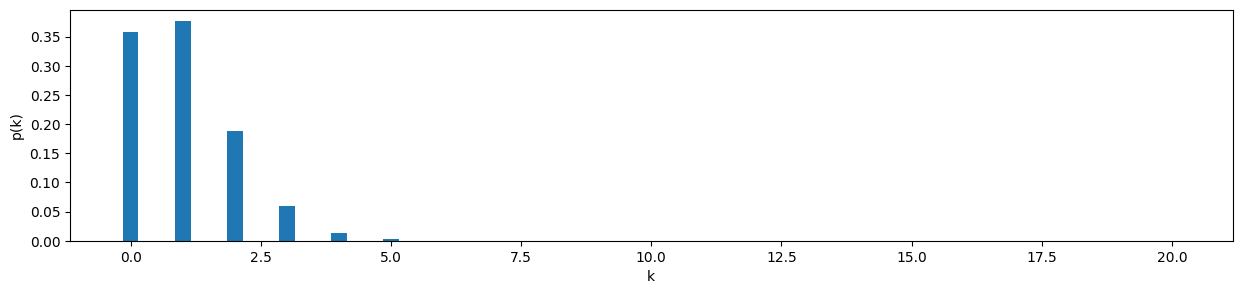

In [44]:
plt.bar( krange, pmf, width=0.3 )
plt.xlabel("k")
plt.ylabel("p(k)")

### c)

**What is the probability that more than 3 pumps are defective on a production day? Use the cumulative
   distribution function (CDF)**

3 or less pumps faulty:

In [45]:
stats.binom.cdf(n=20, k=3, p=0.05)

0.9840984739802364

3 or more pumps faulty:

In [46]:
1-stats.binom.cdf(n=20, k=3, p=0.05)

0.01590152601976358

1.6%!

### d)

**On one day, 10 pumps are defective. What is the probability for this event and what do you suspect happened?**

The probably for 10 pumps to be faulty is extremely small (one in every 100 million days..):

In [47]:
stats.binom.pmf(n=20, k=10, p=0.05)

1.0802758002531833e-08

Probably a machine is broken or a bad batch of input materials was used!

## Exercise 4: Expectation of a PMF

Many count variables follow a **Poisson distribution**. The PMF of the Poisson distribution is
$$
p(k) = P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!},
$$
where $k \in \mathbb{N}_0$ (including $0$) and $\lambda \in \mathbb{R}$ is a parameter.

Show that the **expectation** (mean) of the Poisson distribution is
$$
\mathbb{E}[X] = \lambda.
$$

**Hint.** Use
$$
\mathbb{E}[X] = \sum_{k=0}^{\infty} k\,p(k) = \sum_{k=1}^{\infty} k\,p(k),
$$
and at an appropriate time introduce the new index $\ell = k - 1$.

Finally, remember that
$$
e^{\lambda} = \sum_{\ell = 0}^{\infty} \frac{\lambda^{\ell}}{\ell!}.
$$


$$
\begin{eqnarray}
E[X] &=& \sum_{k=0}^\infty k \; p(k) \\
 &=& \sum_{k=1}^\infty k \; \frac{\lambda^k \; e^{-\lambda}}{k!} \quad\quad \text{term with $k=0$ drops anyway} \\
     &=& e^{-\lambda} \sum_{k=1}^\infty k \; \frac{\lambda^k}{k!} \quad\quad \text{take $e^{-\lambda}$ out of the sum} \\
     &=& e^{-\lambda} \sum_{k=1}^\infty \frac{\lambda^k}{(k-1)!} \quad\quad \text{take $k$ into the factorial} \\
     &=& e^{-\lambda} \sum_{l=0}^\infty \frac{\lambda^{l+1}}{l!} \quad\quad l \equiv k-1 \\
     &=& e^{-\lambda} \; \lambda \; \underbrace{\sum_{l=0}^\infty \frac{\lambda^l}{l!}}_{e^\lambda} \quad\quad \lambda^{l+1} = \lambda^l \cdot \lambda\\
     &=& e^{-\lambda} \; e^\lambda \; \lambda \quad\quad e^{-\lambda} \; e^{\lambda} = 1\\
     &=& \lambda
\end{eqnarray}
$$

This exercise was certainly not trivial and is not exam material. However we hope it served as a reminder about the mechanics in the expectation of a distribution and in particular of the Poisson distribution that we will use a few times within the coming weeks.

## Exercise 5: Maximum likelihood estimator

This exercise anticipates what we will be studying in next week's lecture and is a repetition of the frequentist
**maximum likelihood principle**.

Consider the following problem: A coin has been tossed $n = 10$ times, out of which it came up with heads $k = 8$ times.
What is a likely value for the coin's probability of heads $\pi$?

In your frequentist education, you have learnt that
$$
\hat{\pi} = \frac{k}{n}
$$
is a good estimator. In fact, it is the so-called **maximum likelihood estimator** for the binomial distribution that we
want to derive in this exercise, in order to be better able to distinguish between frequentist and Bayesian inference.

The probability to observe a particular outcome (number of heads) can be computed with the binomial distribution:
$$
P(Y = k \mid \pi) = \binom{n}{k} \,\pi^k (1 - \pi)^{n-k}.
$$

In the maximum likelihood method, we look for the value of $\pi$ that is most likely to have produced our observation.
In other words, we are looking for the value of $\pi$ that yields the maximum value for $P(Y = 8 \mid \pi)$.

To this end, one typically defines the **likelihood function**
$$
L(\pi \mid Y = k) \equiv P(Y = k \mid \pi),
$$
with domain $\pi \in [0,1]$. Note that $L$ is *not* a probability distribution over $\pi$ (it does not integrate to $1$);
for this reason Sir Ronald Fisher called it *likelihood* rather than probability. In maximum likelihood, $L$ is maximized.


### a)

Use the first derivative with respect to $\pi$ to show that the estimator $\hat{\pi} = k/n$ maximizes $L$ for given
   $k$ and $n$:
   $$
   \frac{\mathrm{d}}{\mathrm{d}\pi} L(\pi \mid Y = k) = 0.
   $$
   For simplicity, assume that $\pi \in (0,1)$, i.e. $\pi \notin \{0,1\}$.

$$
\begin{eqnarray}
 \frac{\text{d}}{\text{d}\pi} L(\pi \; | \; Y=k) &=& \begin{pmatrix} n \\ k \end{pmatrix} \frac{\text{d}}{\text{d}\pi} \left[\pi^k \; (1-\pi)^{n-k} \right] \\
  &=& \begin{pmatrix} n \\ k \end{pmatrix} \left[k \; \pi^{k-1} \; (1-\pi)^{n-k} + \pi^k \; (1-\pi)^{n-k-1} \; (-1) \right] \\
  &=& \begin{pmatrix} n \\ k \end{pmatrix} \pi^{k-1} \; (1-\pi)^{n-k-1} \underbrace{\left[ k\;(1-\pi) - (n-k)\;\pi\right]}_{=0}  = 0
\end{eqnarray}
$$

$$
k\;(1-\pi) - (n-k)\;\pi = k - n\;\pi = 0 \quad \Rightarrow \quad \hat{\pi} = \frac{k}{n}
$$

Believe it or not, but it's the same maths that yield $\hat{\boldsymbol{\beta}} = (X^T X)^{-1} \, X^T \, \mathbf{y}$ as maximum likelihood solution for a linear regression with design matrix $X$ and outcomes $\mathbf{y}$.

### b)

Use NumPy and Matplotlib to **plot $L(\pi \mid Y = 8)$ for different values of $\pi$** and verify that the maximum
   is at $\hat{\pi}$. (Hint: Use `scipy.stats.binom.pmf()` to compute $L(\pi \mid Y = 8)$.)

Compute likelihood values:

In [48]:
from scipy.stats import binom
pi_values = np.arange(0,1.1,0.05)
probs = [binom.pmf(k=8, n=10, p=pi) for pi in pi_values]

Plot:

Text(0, 0.5, '$L(\\pi|k=8)$')

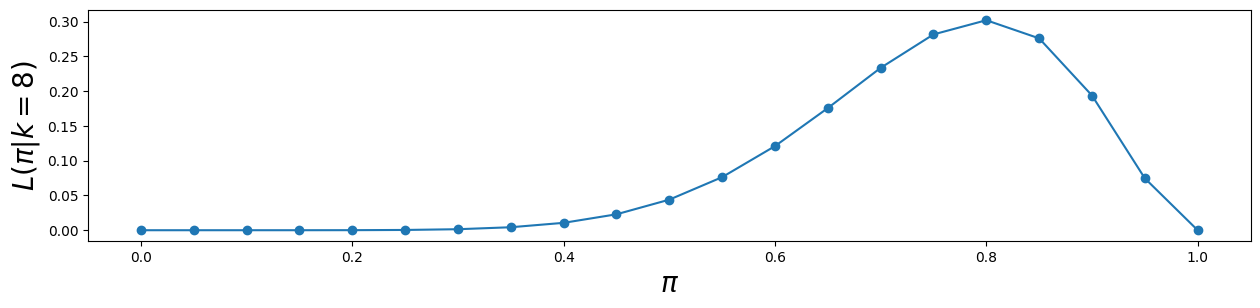

In [49]:
plt.figure( figsize=(15,3) )
plt.plot( pi_values, probs, marker="o" )
plt.xlabel("$\pi$", fontsize=20)
plt.ylabel("$L(\pi|k=8)$", fontsize=20)

## Exercise 6: Fighting terrorism

You work for the Swiss government and are in discussions with a security contractor who offers you a **face detection
software** that could be installed at Zurich main station. The following are its performance measures:

- Given that a person is registered as a terrorist, it finds them with probability **$95\%$**.
- Innocent citizens are incorrectly recognized as terrorists with probability **$0.01\%$**.

Using appropriate probabilistic reasoning (e.g. Bayes' theorem and reasonable assumptions on base rates), answer:

> Would you buy their system and employ it?


According to Wikipedia, 471'300 people walk through Zurich mainstation every day. Your system would flag 47 people as terrorists every day that would need to be arrested and investigated. With the very small rate of potential terrorists in Switzerland, almost all of the arrested people will be innocent. This would firstly be extremely expensive and secondly result in unpleasant consequences for the arrested people. Better not buy the system!

## Exercise 7: Prison populations in Switzerland

In 2024, $70.1\%$ of all prison inmates in Switzerland were **not** of Swiss nationality. One might be inclined to conclude
that the majority of Switzerland's inhabitants without a Swiss passport are criminal.

Using **Bayes' theorem**, show that this is not a correct interpretation and needs to be put into perspective. In particular,
use the following additional numbers:

- There are $8.74$ million inhabitants in Switzerland.
- About $27\%$ of these $8.74$ million inhabitants are **not** of Swiss nationality.
- About $6400$ of these $8.74$ million inhabitants are currently in prison.

Given events

- $P$: “person is in prison”,
- $S$: “person is of Swiss nationality”,

compute, compare and interpret the probabilities

- $P(P \mid S)$ and
- $P(P \mid \bar{S})$.


### $P(P|S)$:

We need to employ Bayes' theorem here:

$P(P|S) = \frac{P(S|P) \; P(P)}{P(S)}.$

Let's go through the individual quantities bit by bit.

$P(P)$:

In [50]:
PP = 6400 / 8740000
PP

0.0007322654462242563

The probability that a randomly selected inhabitant is in prison is 0.073%! (one in 1366 people).

$P(S), P(\overline{S})$:

In [51]:
PnotS = 0.27
PS = 1-PnotS
PS

0.73

$P(S|P)$:

In [52]:
PnotSgivenP = 0.7
PSgivenP = 1 - PnotSgivenP
PSgivenP

0.30000000000000004

Compute result for $P(P|S)$ via Bayes' theorem:

In [53]:
PPgivenS = PSgivenP * PP / PS
PPgivenS

0.0003009310052976396

The probability that a person with Swiss nationality is in prison is 0.03% (one person in 3300).

### $P(P|\overline{S})$:

$\displaystyle{P(P|\overline{S}) = \frac{P(\overline{S}|P) \; P(P)}{P(\overline{S})}}$

$P(\overline{S}|P) = 1- P(S|P)$:

In [54]:
PnotSgivenP = 1 - PSgivenP
PnotSgivenP

0.7

Compute result for $P(P|\overline{S})$:

In [55]:
PPgivennotS = PnotSgivenP * PP / PnotS
PPgivennotS

0.0018984659716925162

The probability that a person without Swiss nationality is in prison is 0.2% (one out 500). It is substantially higher than the probability for a Swiss national to be in prison (more than 6 times likely), but certainly still extremely small.

## Exercise 8: Non-Invasive Prenatal Testing

**Non-invasive prenatal testing (NIPT)** is a blood test to determine the risk for a fetus to be born with trisomy 21, 18,
or 13. The test has to be conducted between week 5 and 7 of pregnancy and is typically only applied when the first trimester
screening (FTS – or *Ersttrimestertest* ETT in German) is conspicuous.

In this exercise, we focus on NIPT's abilities to detect the presence of **Down syndrome (trisomy 21)**. The literature
indicates a **sensitivity** of $99.2\%$ and a **specificity** of $99.91\%$. The prevalence of trisomy 21 depends on age:
at age 20 it's around $0.1\%$ or less, at age 40 it increases significantly towards $1.4\%$.

You have just administered such a test and want to be prepared for what it means to have a positive or negative test result.

Let

- $D$: “Down syndrome present”,
- $T$: “test result is positive”.


### a)

For a **40-year-old woman**, formulate and compute the following probabilities of interest:

   1. $P(D \mid T)$ — that Down syndrome is present given that the test turns out positive.
   2. $P(D \mid \bar{T})$ — that Down syndrome is present given that the test turns out negative.

Important probabilities:

* $P(D) = 0.014$ (prevalence)
* $P(T|D) = 0.992$ (sensitivity)
* $P(\overline{T}|\overline{D}) = 0.9991$ (specificity)
* $P(T|\overline{D}) = 1 - P(\overline{T}|\overline{D})$ (false positive rate)

In [56]:
preval = 0.014
sens = 0.992
spec = 0.9991

$P(T)$ over marginalization:

$$
\begin{eqnarray}
P(T) &=& P(T|D) \; P(D) + P(T|\overline{D}) \; P(\overline{D}) \\
     &=& P(T|D) \; P(D) + (1-P(\overline{T}|\overline{D})) \; (1-P(D))
\end{eqnarray}
$$

In [57]:
PT = sens * preval + (1-spec) * (1-preval)
PT

0.014775400000000013

Probability that Down syndrom is present given test is positive:

$$P(D|T) = \frac{P(T|D) P(D)}{P(T)}$$

In [58]:
PDT = sens * preval / PT
PDT

0.9399407122649802

If the test is positive, then in 93% the Down syndrome will actually be present. Compared to other examples, this is quite high!

Probability that Down syndrom is present given test is negative:

$$P(D|\overline{T}) = \frac{P(\overline{T}|D) P(D)}{P(\overline{T})} = \frac{(1-P(T|D))\;P(D)}{1-P(T)}$$

In [59]:
PDnotT = (1-sens) * preval / (1-PT)
PDnotT

0.0001136796624850822

If the test is negative, then chances that the Down syndrome is present nevertheless are extremely small, with a probability of 0.001%.

### b)

Answer the same questions for a **20-year-old woman** and explain the principal reason why NIPT is typically *not* used
   on 20-year-old women.

Change prevalence and do the same computations again:

In [60]:
preval = 0.001

In [61]:
PT = sens * preval + (1-spec) * (1-preval)
PDT = sens * preval / PT
PDnotT = (1-sens) * preval / (1-PT)
PDT, PDnotT

(0.5245624239860366, 8.01515746428071e-06)

The probabilities have changed significantly! Now the probability is only 52% that the Down syndrom is actually present given that the test is positive. This is extremely large, every second fetus would be a false positive in this test, possibly unsettling its future parents and leading them to administer further risky invasive tests, such as puncture of the amnion. **The reason for this discrepancy has nothing to do with the test! Sensitivity and specificity stayed the same, but the reduced prevalence significantly increases the chance of false positives!**

### c)

Using the same argument as in b), argue that the probability that you actually have Covid-19 given a positive Covid-19
   self-test was a **time-varying function** between 2020–2022. What causes the variability over time?

The prevalence of Covid-19 changed throughout the pandemic (see e.g. [here](https://sjes.springeropen.com/articles/10.1186/s41937-022-00083-7/figures/1) ) while sensitivity and specificity of the tests stayed roughly constant.

## Exercise 9: Magic coin

You bought a **magic coin** from a wizard shop. Unfortunately, you have thrown away the instruction manual and cannot
remember whether the coin is biased towards heads or towards tails. This is important, since you have to perform a magic
trick in a few minutes. You call the company and they tell you that the coin comes in two models:

- Model 1 with $\pi = 0.2$ (probability to show heads is $20\%$ in the long run) is sold in $10\%$ of the cases.
- Model 2 with $\pi = 0.8$ is sold in $90\%$ of the cases.


### a)

You throw the coin 5 times and it shows heads twice. With your limited amount of data, what model do you think it is?

   **Hint.** Compute the ratio
   $$
   \frac{P(\pi = 0.8 \mid d)}{P(\pi = 0.2 \mid d)},
   $$
   where $d$ stands for your collected coin-toss data, and use Bayes' theorem together with the binomial distribution.

$$
\begin{eqnarray}
\frac{P(\pi=0.8 \; | \; d)}{P(\pi=0.2 \; | \; d)} &=& \frac{P(d \; | \; \pi=0.8) \; P(\pi=0.8)}{P(d \; | \; \pi=0.2) \; P(\pi=0.2)} \\
&=& \frac{\begin{pmatrix} 5\\ 2 \end{pmatrix} \; 0.8^2 \; 0.2^3 \; \cdot \; 0.9}{\begin{pmatrix} 5\\ 2 \end{pmatrix} \; 0.2^2 \; 0.8^3 \; \cdot \; 0.1} \\
&=& 2.25
\end{eqnarray}
$$

With Python:

In [62]:
(binom.pmf(k=2, n=5, p=0.8) * 0.9) / (binom.pmf(k=2, n=5, p=0.2) * 0.1)

2.2500000000000004

You believe more than twice as much in the hypothesis that it's model number 2!

### b)

Luckily, your magic trick worked and the coin showed heads as you predicted. At home, you have time for more flips.
   Interestingly, you flip the same ratio, just with ten times higher numbers: out of 50 flips, you get heads 20 times.
   How much do you believe now that you have **Model 2**?

In [63]:
ratio = (binom.pmf(k=20, n=50, p=0.8) * 0.9) / (binom.pmf(k=20, n=50, p=0.2) * 0.1)
ratio

8.583068847656159e-06

In [64]:
1/ratio

116508.44444444569

You believe over 100'000 times more in model 1 than in model 2 now! The collected data have overruled your prior!

### c)

Argue why a **frequentist magician** would have failed at this task.

The frequentist magician would have estimated $\pi \approx 0.4$ and favoured model 1. In his methods he has no way to introduce prior knowledge. On stage he would later have failed terribly!

### d)

Under what circumstance would you (the **Bayesian** magician) and the **frequentist** magician come to the same
   conclusion?

   Hint: The frequentist cannot use the above posterior ratio for decision making, but only
   $$
   \frac{P(d \mid \pi = 0.8)}{P(d \mid \pi = 0.2)}.
   $$
   When are these two ratios the same?

If both coins would have been sold equally often, i.e. $P(\pi=0.2) = P(\pi=0.8) = 0.5$. Then

$$
\frac{P(\pi=0.8 \; | \; d)}{P(\pi=0.2 \; | \; d)} = \frac{P(d \; | \; \pi=0.8) \; P(\pi=0.8)}{P(d \; | \; \pi=0.2) \; P(\pi=0.2)} = \frac{P(d \; | \; \pi=0.8)}{P(d \; | \; \pi=0.2)}.
$$

## Exercise 10: Covid symptoms

In 2021, the Israeli Ministry of Health publicly released data of all individuals who were tested for SARS-CoV-2 via
PCR nasopharyngeal swab (see `covid_tests.csv` in the exercise material on Moodle). The dataset lists the result of the
Covid test and the symptoms of the test subject.

You are a data scientist (from 2021) and want to create a simple rule for how individuals are to be **prioritized for a test**
according to their symptoms (anticipating a shortage of the available Covid tests).


### a)

Read the data from the CSV with pandas and perform the following actions:

   - Select only the columns `'corona_result'` (result of the test) and the symptoms
     `'cough'`, `'fever'`, `'sore_throat'`, `'shortness_of_breath'` and `'head_ache'`.
   - Filter out only `'positive'` and `'negative'` test results.
   - Replace `'positive'` test results with `1` and `'negative'` with `0`.

Read CSV file:

In [65]:
df = pd.read_csv("data/covid_tests.csv")
df.sample(5)

/var/folders/mg/f7gk10vj1_153rz1zkvd13_00000gn/T/ipykernel_97751/1560312382.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/covid_tests.csv")


,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
32941,2020-04-25,0.0,0.0,0.0,0.0,0.0,negative,NaN,male,Other
235648,2020-03-27,0.0,0.0,0.0,0.0,0.0,negative,No,female,Other
203131,2020-04-01,0.0,0.0,0.0,0.0,1.0,negative,No,female,Contact with confirmed
219768,2020-03-30,1.0,0.0,0.0,0.0,0.0,negative,No,female,Abroad
58144,2020-04-22,0.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other


Drop irrelevant columns, filter only positive and negative results and map them to 1 and 0 respectively:

In [66]:
df = df.drop(["test_date", "age_60_and_above", "gender", "test_indication"], axis=1 )
df = df[df.corona_result.isin(["positive", "negative"])]
df.corona_result = df.corona_result.replace({'positive': 1.0, 'negative': 0.0})
df.sample(5)

/var/folders/mg/f7gk10vj1_153rz1zkvd13_00000gn/T/ipykernel_97751/3175961417.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.corona_result = df.corona_result.replace({'positive': 1.0, 'negative': 0.0})


,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result
11196,0.0,0.0,0.0,0.0,0.0,0.0
29679,0.0,0.0,0.0,0.0,0.0,0.0
131835,1.0,0.0,0.0,0.0,0.0,0.0
43996,0.0,0.0,0.0,0.0,0.0,0.0
19109,0.0,0.0,0.0,0.0,0.0,0.0


(ignore the future warnings..)

### b)

Using the dataset, compute the conditional probabilities $P(\text{covid} \mid \text{cough})$ and
   $P(\text{cough} \mid \text{covid})$.

P(covid|cough):

In [67]:
df[df.cough==1].corona_result.mean()

0.15837963965264246

P(cough|covid):

In [68]:
df[df.corona_result==1].cough.mean()

0.44801306477953184

These probabilities are quite different! It is quite likely that you cough given that you have covid, but less likely that you have covid if you cough.

### c)

Use your pandas skills to compute all values for $P(\text{symptom} \mid \text{covid})$ and
   $P(\text{covid} \mid \text{symptom})$.

   Hint: $P(\text{symptom} \mid \text{covid})$ is easy to compute in a vectorized way using `groupby()`. The inverse
   probability is more difficult to do in a vectorized way, but it works if you compute the marginal probabilities
   $P(\text{symptom})$ and $P(\text{covid})$ and multiply / divide them with $P(\text{symptom} \mid \text{covid})$ according
   to Bayes' theorem.

P(symptom|covid):

In [69]:
P_symptoms_given_covid = df[df.corona_result==1].drop('corona_result', axis=1).mean()
P_symptoms_given_covid

cough                  0.448013
fever                  0.378266
sore_throat            0.103612
shortness_of_breath    0.079033
head_ache              0.151752
dtype: float64

Marginal probabilities:

P(symptom):

In [70]:
P_symptoms = df.drop('corona_result', axis=1).mean()
P_symptoms

cough                  0.151330
fever                  0.077811
sore_throat            0.006881
shortness_of_breath    0.005634
head_ache              0.008667
dtype: float64

P(covid):

In [71]:
P_covid = df.corona_result.mean()
P_covid

0.053568570971355416

Apply Bayes' theorem to get P(covid|symptom):

In [72]:
P_covid_given_symptoms = P_symptoms_given_covid / P_symptoms * P_covid
P_covid_given_symptoms

cough                  0.158590
fever                  0.260415
sore_throat            0.806606
shortness_of_breath    0.751501
head_ache              0.937954
dtype: float64

(the value for cough is the same one as we computed in b))

### d)

Which one would you rather use to prioritize individuals for Covid tests,
   $P(\text{symptom} \mid \text{covid})$ or $P(\text{covid} \mid \text{symptom})$?
   List the symptoms from highest to lowest priority and argue that it makes a big difference which conditional probability
   you use.

Of course we want to sort out the invidiuals with the highest risk of suffering from Covid-19 and are therefore interested in P(covid|symptom). The order of priority is, from highest to lowest: head ache, sore throat, shortness of breath, fever and finally cough. The other probability P(symptom|covid) gives an almost inverted order and is not relevant for this problem!

## Exercise 11: Sick trees

This exercise is borrowed from the book *Bayes Rules!*.

A local arboretum contains a variety of tree species, including elms, maples, and others. Unfortunately,
$18\%$ of all trees in the arboretum are infected with mold. Among the infected trees,

- $15\%$ are elms,
- $80\%$ are maples,
- $5\%$ are other species.

Among the uninfected trees,

- $20\%$ are elms,
- $10\%$ are maples,
- $70\%$ are other species.

In monitoring the spread of mold, an arboretum employee randomly selects a tree to test.


### a)

What is the **prior probability** that the selected tree has mold?

$P(\text{mold}) = 18\%$

### b)

The tree happens to be a maple. What is the probability that the employee would have selected a maple?

Use marginalisation:

$$
\begin{eqnarray}
P(\text{maple}) &=& P(\text{maple} | \text{mold}) \; P(\text{mold}) + P(\text{maple} | \overline{\text{mold}}) \; P(\overline{\text{mold}}) &=& 0.8 \cdot 0.18 + 0.1 \cdot 0.82 = 0.226
\end{eqnarray}
$$

In [73]:
Pmaple = 0.8 * 0.18 + 0.1 * 0.82
Pmaple

0.22599999999999998

The probability to select a maple is 22.6%!

### c)

 What is the **posterior probability** that the selected maple tree has mold?

$$P(\text{mold}|\text{maple}) = \frac{P(\text{maple} | \text{mold}) \; P(\text{mold})}{P(\text{maple})} \approx 63.7% $$

In [74]:
Pmold_given_maple = 0.8 * 0.18 / Pmaple
Pmold_given_maple

0.6371681415929203

### d)

Compare the prior and posterior probability of the tree having mold. How did your understanding change in light of
   the fact that the tree is a maple?

Knowing that it's a maple raised the prior probability of mold from 18% to 63.7%. This makes sense, as maples are over-represented in infected trees and under-represented in healthy trees.

### e)

How close is the simulated posterior probability to the one computed in (c) with Bayes' theorem? Take some time to ponder
why this simulation works. In the literature, this type of simulation is often called **ancestral sampling**, since it
samples from two hierarchical levels.

There is another way to compute the posterior probability using a **simulation**! Proceed as follows:

   1. Simulate $10{,}000$ random trees and whether they have mold with `np.random.choice()` according to the prior
      probability $P(\text{mold})$ and store your results in a data frame.
   2. Assign a maple probability ($P(\text{maple} \mid \text{mold})$ or $P(\text{maple} \mid \text{no mold})$) from the
      description above to each tree according to whether the tree has mold or not.
   3. For each tree, randomly sample whether it's a maple using `np.random.choice()` and $P(\text{maple} \mid \text{mold})$.
   4. Compute $P(\text{mold} \mid \text{maple})$ by filtering out only maple trees and computing the ratio of them that
      have mold.

Simulate 10'000 random trees and decide whether they have mold using P(mold):

In [75]:
sim = pd.DataFrame( {'mold': np.random.choice([0,1], p=[0.82, 0.18], size=10000)} )
sim.head()

,mold
0,0
1,0
2,0
3,0
4,0


Assign the probability that it's a maple using P(maple|mold):

In [76]:
sim['p_maple'] = sim.mold.map({0: 0.1, 1: 0.8})
sim

,mold,p_maple
0,0,0.1
1,0,0.1
2,0,0.1
3,0,0.1
4,0,0.1
...,...,...
9995,1,0.8
9996,0,0.1
9997,1,0.8
9998,0,0.1


Sample whether it's a maple:

In [77]:
sim['maple'] = sim.p_maple.apply( lambda x: np.random.choice([0,1], p=[1-x,x]) )
sim.head()

,mold,p_maple,maple
0,0,0.1,0
1,0,0.1,0
2,0,0.1,0
3,0,0.1,0
4,0,0.1,0


Compute posterior probability P(mold|maple):

In [78]:
Why
this
works:

By
sampling
first
whether
the
tree
has
mold
from $P$(
    mold) = 18\% and then sampling for each tree whether it is a maple from $P$(maple | mold) respectively $P$(maple | $\overline{\text{mold}}$), we have approximated a sample from the joint distribution $P$(maple, mold).It is not difficult to compute the conditional probability $P$(maple | mold) by filtering out just the trees with mold and the computing the proportion of maples.sim[sim.maple==1].mold.mean()

0.6346491228070176

Why this works:

By sampling first whether the tree has mold from $P$(mold) = 18\% and then sampling for each tree whether it is a maple from $P$(maple|mold) respectively $P$(maple|$\overline{\text{mold}}$), we have approximated a sample from the joint distribution $P$(maple, mold). It is not difficult to compute the conditional probability $P$(maple|mold) by filtering out just the trees with mold and the computing the proportion of maples.